<a href="https://colab.research.google.com/github/ankit-rathi/Quantvesting_v3/blob/main/02_portfolio_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantvesting

## Portfolio Analysis

Interactive portfolio analysis with compact summary and category distribution.

In [1]:
!pip install -q ta pyxirr matplotlib


In [2]:
# 1. Environment & imports

from google.colab import drive
drive.mount('/content/drive')

import sys

PROJECT = "/content/drive/My Drive/quantvesting_v3"
MARKET_DATA_DIR = PROJECT + "/market_data"
PORTFOLIO_ID = "ankit"  # change only this value for another user
PORTFOLIO_DATA_DIR = PROJECT + f"/portfolio_data/{PORTFOLIO_ID}"

# Phase A: set True only for the final EOD run.
EOD_RUN = False

sys.path.insert(0, PROJECT + "/src")

from quantvesting import (
    Quantvesting,
    load_config,
    load_market_data,
    load_portfolio_data,
    create_run_id,
    PROSPECT_DISPLAY_COLUMNS,
    PORTFOLIO_DISPLAY_COLUMNS,
)

RUN_ID = create_run_id()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# 2. Load shared market data + this user's portfolio

config = load_config(
    PROJECT + "/config/strategy.yaml"
)

market_data = load_market_data(MARKET_DATA_DIR)
portfolio_data = load_portfolio_data(
    PORTFOLIO_DATA_DIR,
    portfolio_id=PORTFOLIO_ID,
)

qv = Quantvesting(config)


In [4]:
# 3. Run portfolio analysis
# EOD_RUN=False -> analysis only
# EOD_RUN=True  -> replace/create today's IST snapshot in myPortfolioDB.csv

df_portfolio, portfolio_summary = qv.portfolio(
    market_data,
    portfolio_data=portfolio_data,
    eod=EOD_RUN,
    portfolio_id=PORTFOLIO_ID,
    run_id=RUN_ID,
)


/content/drive/My Drive/quantvesting_v3/src/quantvesting/portfolio.py:436: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates = pd.to_datetime(dates)


In [5]:
# 4. Interactive portfolio view

qv.display_dataframe(
    df_portfolio,
    columns=PORTFOLIO_DISPLAY_COLUMNS,
    sort_by="FTT Amt",
    ascending=True,
)


,Symbol,Today P/L%,Current P/L%,FTT%,OTT%,FTT Amt,Current P/L,Current,FTT,Dev%_PE,RSI_14,Conviction,Spread%,CumlRnk,RRR Ind,CurrAlloc%,Gained%,Criteria,Strategy,Category
78,UNITDSPR,-0.34,11.34,8.46,20.77,22055.0,26556.0,260700.0,1644.00,-5.11,58.0,X-MC,11.24,64.0,1.20,1.69,25.32,X40N,NTT,BREWERIES
77,TTKPRESTIG,-0.78,-23.31,30.52,0.09,23587.0,-23494.0,77283.0,770.00,-6.68,41.0,M-SC,9.70,250.0,-1.00,0.50,39.10,OX40N,NTT,DURABLES
52,M&M,-0.34,7.68,10.35,18.82,26823.0,18479.0,259160.0,3762.88,-6.96,57.0,X-LC,4.85,25.0,0.69,1.68,17.56,X40N,ATH,AUTO
67,SIS,0.82,-4.23,26.62,21.26,28306.0,-4697.0,106335.0,528.00,104.27,40.0,H-SC,20.87,168.0,-0.17,0.69,58.10,OX40N,NTT,MISC
27,GLAXO,5.14,21.44,11.73,35.69,28388.0,42732.0,242016.0,3380.16,-8.92,85.0,X-MC,9.86,56.0,1.51,1.57,43.84,X40,ATH,PHARMA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9,BANDHANBNK,-0.53,-18.41,135.85,92.42,308738.0,-51295.0,227264.0,400.00,45.11,37.0,H-SC,11.68,174.0,-0.17,1.48,26.28,XY24,NTT,BANKS
2,ACC,-1.29,-42.40,203.50,74.81,314285.0,-113688.0,154440.0,3906.00,-42.69,34.0,X-SC,11.71,85.0,-0.36,1.00,3.18,XY24,BTT,CEMENT
62,REPCOHOME,3.11,-22.13,143.77,89.82,320748.0,-63407.0,223098.0,880.00,NaN,36.0,H-nan,4.27,161.0,-0.20,1.45,7.25,XY24,NTT,FINANCE
6,AWL,-0.76,-35.06,157.17,67.02,363691.0,-124909.0,231400.0,485.00,-52.14,45.0,X-SC,8.69,81.0,-0.34,1.50,10.03,XY24,NTT,FMCG


In [6]:
# 5. Compact portfolio summary

qv.display_run_summary(portfolio_summary)


## Run date time (IST): 2026-08-19 15:30:25

Deployed:  1.46 C  
Current:  1.58 C  
CAGR/XIRR %: 3.44%

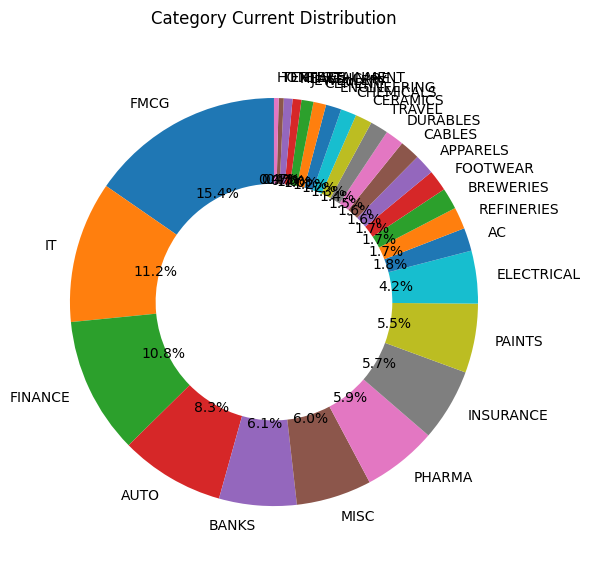

,Current
Category,
FMCG,2365683.0
IT,1722691.0
FINANCE,1664730.0
AUTO,1273052.0
BANKS,944626.0
MISC,918881.0
PHARMA,907374.0
INSURANCE,882210.0
PAINTS,843597.0


In [7]:
# 6. Current portfolio category distribution

qv.display_portfolio_category_chart(
    df_portfolio,
    category_column="Category",
    value_column="Current",
    title="Category Current Distribution",
)


### Optional decision layer

In [8]:
# 7. Portfolio actions

df_portfolio_actions = qv.portfolio_actions(df_portfolio)

qv.display_dataframe(
    df_portfolio_actions,
    columns=PORTFOLIO_DISPLAY_COLUMNS,
    sort_by="CurrAlloc%",
    ascending=False,
)


,Symbol,Today P/L%,Current P/L%,FTT%,OTT%,FTT Amt,Current P/L,Current,FTT,Dev%_PE,RSI_14,Conviction,Spread%,CumlRnk,RRR Ind,CurrAlloc%,Gained%,Criteria,Strategy,Category
75,TMPV,-0.20,-23.35,86.25,42.75,275075.0,-97179.0,318928.0,600.00,-84.91,36.0,X-LC,4.52,4.0,-0.35,2.07,9.66,XY24,NTT,AUTO
68,STARHEALTH,-0.15,12.82,30.53,47.26,96827.0,36029.0,317152.0,761.00,-0.61,50.0,H-SC,16.27,173.0,0.37,2.06,37.13,XY24,NTT,INSURANCE
48,JIOFIN,-1.38,-16.02,59.65,34.08,186523.0,-59650.0,312696.0,387.00,-34.63,44.0,X-LC,6.19,34.0,-0.32,2.03,8.42,XY24,BTT,FINANCE
73,TCS,0.33,-32.84,84.94,24.20,264260.0,-152159.0,311114.0,4230.71,-44.31,47.0,X-LC,14.11,2.0,-0.58,2.02,16.02,X40,ATH,IT
82,VBL,-1.50,-12.31,54.71,35.66,168789.0,-43329.0,308515.0,669.42,-28.32,37.0,X-LC,7.00,13.0,-0.26,2.00,13.59,X40N,ATH,FMCG
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18,COFFEEDAY,-0.67,-50.22,171.74,35.27,97076.0,-57024.0,56525.0,80.00,NaN,40.0,L-nan,3.80,266.0,-0.59,0.37,39.39,XR,NTT,HOTELS
63,ROUTE,-0.08,-62.12,338.98,66.28,170859.0,-82662.0,50404.0,2190.73,NaN,36.0,H-nan,5.49,141.0,-0.48,0.33,21.44,SR,ATH,IT
58,RAJOOENG,0.63,-50.06,179.55,39.61,91912.0,-51310.0,51190.0,143.10,NaN,46.0,H-nan,15.97,136.0,-0.56,0.33,9.66,AR,ATH,MISC
21,DEN,-0.15,-48.15,174.02,42.07,76207.0,-40672.0,43792.0,75.00,NaN,45.0,M-nan,5.58,235.0,-0.53,0.28,19.10,AR,NTT,ENTERTAINMENT
